# 02b – EDA over alle jaren (2013–2026): wat verandert er als we alle data gebruiken?

| | |
|---|---|
| **Auteur(s)** | Kobe Vandenberk |
| **Wat** | In `02_eda_cleaning` onderzochten we 2024 in detail. Hier kijken we naar wat er *bijkomt* met 13 jaar data: andere bestandsformaten, dubbele bestanden, een nieuw systeem van station-id's, de groei van het netwerk, corona, en maanden met ontbrekende data. Dat bepaalt hoe `04_prepare_data` de modeltabel over alle jaren bouwt. |
| **Input** | `data/raw/*.zip`, `data/audit.json`, `data/stations.parquet`, `data/station_hour/*.parquet`, `data/trips_sample.parquet`, `data/weather.parquet` (uit `01_download`) |
| **Output** | keuzes die `04_prepare_data` toepast |
| **GenAI** | Code en tekst opgesteld met hulp van Claude; keuzes en resultaten nagekeken door Kobe. |

De cleaningregels uit 2024 (vertrek = starttijd + startstation + locatie in NYC; geen filter op ritduur; interne en JC/HB-stations weg) blijven gelden. Hier gaat het over wat specifiek is aan de oudere jaren.

## 0. Imports en data

In [1]:
%matplotlib inline
import json
from collections import Counter
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import citibike as cb

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})
GREEN, ORANGE, INK, BLUE = "#2f6f4f", "#c47f00", "#17201b", "#3b6fb6"

audit_all = json.loads((cb.DATA_DIR / "audit.json").read_text(encoding="utf-8"))
audit = pd.json_normalize([a for a in audit_all if "rows" in a]).set_index("month").sort_index()
dropped = [a for a in audit_all if "rows" not in a]
stations = pd.read_parquet(cb.DATA_DIR / "stations.parquet")
sample = pd.read_parquet(cb.DATA_DIR / "trips_sample.parquet")
weather = pd.read_parquet(cb.DATA_DIR / "weather.parquet")
manifest = json.loads((cb.RAW_DIR / "manifest.json").read_text(encoding="utf-8"))
print(f"{len(audit)} maanden ({audit.index.min()}–{audit.index.max()}), {audit['rows'].sum():,} ritten, "
      f"{len(stations):,} station-id's, steekproef {len(sample):,} ritten")

160 maanden (201306–202609), 328,800,493 ritten, 3,824 station-id's, steekproef 657,661 ritten


## 1. Hoe zijn de bestanden opgebouwd?
We lezen van elk bronbestand de kolomnamen van de eerste gebruikte CSV.

In [2]:
schemas = []
for record in manifest:
    keep, _ = cb.select_csvs(record["csv_files"])
    with ZipFile(cb.RAW_DIR / record["file"]) as archive:
        for full, holder, name in cb._walk_zip(archive):
            if full == keep[0]:
                with holder.open(name) as handle:
                    columns = list(pd.read_csv(handle, nrows=0).columns)
                break
    schemas.append({"bestand": record["file"], "CSV's": len(record["csv_files"]), "gebruikt": len(keep),
                    "kolommen": ", ".join(columns[:5]) + (", ..." if len(columns) > 5 else ""), "n_kolommen": len(columns)})
schemas = pd.DataFrame(schemas)
schemas.drop_duplicates(subset=["kolommen", "n_kolommen"], keep="first")

,bestand,CSV's,gebruikt,kolommen,n_kolommen
0,2013-citibike-tripdata.zip,17,10,"tripduration, starttime, stoptime, start stati...",15
3,2016-citibike-tripdata.zip,20,20,"Trip Duration, Start Time, Stop Time, Start St...",15
7,2020-citibike-tripdata.zip,27,27,"ride_id, rideable_type, started_at, ended_at, ...",13


**Vaststelling:** drie generaties kolomnamen.
- **2013–2015 en de meeste bestanden van 2016–2019**: `tripduration, starttime, stoptime, start station id, ...` (15 kolommen, met ook `bikeid`, `usertype` (*Subscriber*/*Customer*), `birth year` en `gender`);
- **sommige bestanden van 2016–2017**: dezelfde kolommen met hoofdletters en spaties (`Trip Duration, Start Time, ...`);
- **vanaf 2020/2021**: het schema van vandaag (`ride_id, rideable_type, started_at, ...`, 13 kolommen), zonder leeftijd en geslacht maar met fietstype.

`standardize_columns` zet alles om naar het huidige schema: kolomnamen naar kleine letters met `_`, en `starttime`/`start_time` → `started_at`, `usertype` → `member_casual` (*Subscriber* → member, *Customer* → casual). Kolommen die vroeger niet bestonden, worden leeg (`ride_id`) of `unknown` (`rideable_type`).

## 2. Dubbele versies van dezelfde maand
De zip van 2013 bevat elke maand twee keer: als één los bestand én opgesplitst in een maandmap. Gebruiken we beide, dan tellen we die ritten dubbel. Bewijs dat het om dezelfde ritten gaat: we tellen en vergelijken de ritten van september 2013 in beide versies.

In [3]:
print("Weggelaten:", [Path_ for a in dropped for Path_ in a["csv_files"]][:3], "...")
versions = {}
with ZipFile(cb.RAW_DIR / "2013-citibike-tripdata.zip") as archive:
    for full, holder, name in cb._walk_zip(archive):
        if cb.csv_month(full) == "201309":
            with holder.open(name) as handle:
                part = cb.standardize_columns(pd.read_csv(handle, dtype=str))
            key = "los bestand" if full.count("/") == 1 else "maandmap"
            versions.setdefault(key, []).append(part)
versions = {k: pd.concat(v, ignore_index=True) for k, v in versions.items()}
for key, frame in versions.items():
    print(f"{key:12}: {len(frame):>9,} ritten, eerste start {frame['started_at'].iloc[0]}")
a, b = (cb.parse_chunk(v)[["started_at", "start_station_id", "end_station_id"]] for v in versions.values())
same = pd.merge(a.value_counts().rename("n").reset_index(), b.value_counts().rename("n").reset_index(),
                on=["started_at", "start_station_id", "end_station_id", "n"]).n.sum()
print(f"Ritten die in beide versies identiek voorkomen (starttijd + start- en eindstation): {same:,}")

Weggelaten: ['2013-citibike-tripdata/201306-citibike-tripdata.csv', '2013-citibike-tripdata/201307-citibike-tripdata.csv', '2013-citibike-tripdata/201308-citibike-tripdata.csv'] ...


los bestand : 1,034,359 ritten, eerste start 2013-09-01 00:00:02
maandmap    : 1,034,359 ritten, eerste start 2013-09-01 00:00:02


Ritten die in beide versies identiek voorkomen (starttijd + start- en eindstation): 1,034,359


**Interpretatie:** beide versies van september 2013 bevatten exact dezelfde **1.034.359 ritten**, en elke rit (starttijd + start- en eindstation) komt in beide voor. Het is dus dezelfde data in een ander bestand. `select_csvs` houdt per maand de versie in de maandmap; zo zijn in totaal 21 dubbele bestanden weggelaten (7 in 2013, 14 in 2018). Zonder die stap zouden 2013 en 2018 dubbel tellen en zou het model een kunstmatige piek in die jaren leren.

## 3. Datumnotaties
Door de jaren heen gebruikte Citi Bike drie notaties. Per rij in de steekproef: welke notatie is het? (We proberen ze in volgorde; de eerste die lukt, telt.)

In [4]:
sample["jaar"] = sample["source_file"].str[:4]
raw = sample["started_at"]
formats = pd.Series("onleesbaar", index=raw.index)
for fmt in reversed(cb.DATE_FORMATS):                       # zo wint de eerste notatie in de lijst
    formats[pd.to_datetime(raw, format=fmt, errors="coerce").notna()] = fmt
pd.crosstab(sample["jaar"], formats, normalize="index").mul(100).round(1)

col_0,%m/%d/%Y %H:%M,%m/%d/%Y %H:%M:%S,ISO8601
jaar,,,
2013,0.0,0.0,100.0
2014,0.0,33.6,66.4
2015,17.6,82.4,0.0
2016,0.0,74.0,26.0
2017,0.0,0.0,100.0
2018,0.0,0.0,100.0
2019,0.0,0.0,100.0
2020,0.0,0.0,100.0
2021,0.0,0.0,100.0


**Vaststelling:** in 2014–2016 wisselt de notatie van bestand tot bestand (bv. `2014-05-23 12:21:13` in het ene, `10/1/2014 00:00:27` in het andere). Daarom bepaalt `cb.to_datetime` de notatie **per stuk van één bestand**, niet per jaar. Het bewijs dat dat werkt: in de audit van `01` ontbreekt voor geen enkel jaar een starttijd (`no_start_time` = 0, en vertrekken ≈ rijen in §4).

In [5]:
print("Ritten zonder leesbare starttijd (alle jaren):", int(audit["no_start_time"].sum()))

Ritten zonder leesbare starttijd (alle jaren): 0


## 4. Datakwaliteit per jaar
Uit de audit van `01` (alle ritten, niet de steekproef):

In [6]:
per_year = (audit.assign(jaar=audit.index.str[:4]).groupby("jaar")
                 [["rows", "departures", "no_start_station", "outside_nyc", "duplicate_rows",
                   "duration_negative", "duration_over_24h", "station_id_fixed"]].sum())
per_year["% gebruikt"] = (per_year["departures"] / per_year["rows"] * 100).round(2)
per_year

,rows,departures,no_start_station,outside_nyc,duplicate_rows,duration_negative,duration_over_24h,station_id_fixed,% gebruikt
jaar,,,,,,,,,
2013,5614888,5614888,0,0,177,0,633,0,100.00
2014,8081216,8081216,0,0,211,0,553,0,100.00
2015,9937969,9937969,0,0,42118,70,2588,0,100.00
2016,13845655,13845652,0,3,7349,83,3579,0,100.00
2017,16364657,16364532,0,125,6539,49,4169,0,100.00
2018,17548339,17545761,2497,81,0,0,4525,8008081,99.99
2019,20551697,20551517,180,0,0,0,6120,7764099,100.00
2020,19562314,19562197,111,6,0,0,15221,0,100.00
2021,27130122,27129629,493,0,0,278,25198,45842,100.00


**Interpretatie:**
- In elk jaar is **meer dan 99,9%** van de ritten bruikbaar. Ontbrekende startstations bestaan pas vanaf 2018 en blijven klein (max. 0,07% in 2024).
- **Dubbele rijen** komen alleen voor in 2013–2017, toen er nog geen ritnummer was en de tijd soms maar tot op de minuut genoteerd werd (2015). Twee mensen die samen vertrekken en aankomen, zijn dan niet te onderscheiden van een dubbele rij. We laten ze staan (max. 0,4% in 2015).
- **Negatieve ritduren** verschijnen elk jaar met een herfst-klokwissel in de data (± 300 per jaar), behalve in 2018–2020 (blijkbaar toen al door Citi Bike gecorrigeerd) en 2026 (nog geen november in de data).
- **Ritten langer dan 24 uur** pieken in 2020–2022 (tot 40.000 per jaar): de jaren waarin e-bikes en ritten zonder eindstation opkwamen. Voor ons tellen ze gewoon als vertrek.
- `station_id_fixed`: in 2018–2019 staan veel oude id's als kommagetal (`119.0`); vanaf 2021 vallen er eindnullen weg (`3423.1`). Beide worden hersteld, afhankelijk van de periode (`normalize_station_id`).

## 5. Twee systemen van station-id's
Tot 2021 had elk station een geheel getal als id (bv. `72`), daarna een code met een punt (bv. `6926.01`). Hetzelfde fysieke station kreeg dus een nieuwe id. Voor ons maakt dat niet uit, zolang we stations via hun **locatie** aan een zone toekennen: oud `72` en nieuw `6926.01` op dezelfde hoek komen in dezelfde zone.

In [7]:
stations["schema"] = np.where(stations["start_station_id"].str.fullmatch(r"\d+"), "oud (geheel getal)",
                              np.where(stations["start_station_id"].str.fullmatch(r"\d+\.\d+"), "nieuw (met punt)", "ander"))
summary = stations.groupby("schema").agg(ids=("start_station_id", "size"), ritten=("trips", "sum"),
                                         eerste_gebruik=("first_time", "min"), laatste_gebruik=("last_time", "max"))
summary

,ids,ritten,eerste_gebruik,laatste_gebruik
schema,,,,
ander,119,51629,2020-01-02 12:00:00,2026-09-30 23:00:00
nieuw (met punt),2645,236714996,2019-01-19 18:00:00,2026-09-30 23:00:00
oud (geheel getal),1060,91941535,2013-06-01 00:00:00,2019-12-31 23:00:00


**Interpretatie:** 1.060 oude id's (gebruikt tot eind 2019) en 2.645 nieuwe id's (vanaf 2019). Samen zijn dat veel meer id's dan er ooit tegelijk stations waren (± 2.400 vandaag): veel stations bestaan onder twee id's. Dat de overgang niet op één dag gebeurde, maar al in 2019 begon, zien we hieronder.

### Gevolg: stations tellen via hun locatie, niet via hun id
Voor het kenmerk "actieve stations" moeten we tellen hoeveel stations er in een maand gebruikt werden. Tellen we **id's**, dan kan hetzelfde station twee keer meetellen: een handvol ritten die in een later bestand staan maar eerder startten, gebruikt al de nieuwe id. We vergelijken per maand het aantal id's met het aantal unieke **locaties** (coördinaten op 4 decimalen, ± 10 m):

In [8]:
location = cb.station_locations(stations)
ids_per_month = []
for path in sorted((cb.DATA_DIR / "station_hour").glob("*.parquet")):
    sh = pd.read_parquet(path, columns=["start_station_id", "time"])
    ids_per_month.append(sh.assign(m=sh["time"].dt.to_period("M"))[["m", "start_station_id"]].drop_duplicates())
ids_per_month = pd.concat(ids_per_month).drop_duplicates()
ids_per_month["locatie"] = ids_per_month["start_station_id"].map(location)
check = ids_per_month.groupby("m").agg(ids=("start_station_id", "nunique"), locaties=("locatie", "nunique"))
check["dubbel geteld"] = check["ids"] - check["locaties"]
check[check["dubbel geteld"] > 3]

,ids,locaties,dubbel geteld
m,,,
2019-04,796,785,11
2019-05,808,793,15
2019-06,809,794,15
2019-07,813,789,24
2019-08,829,798,31
2019-09,862,810,52
2019-10,876,841,35
2019-11,894,871,23
2019-12,1012,888,124


## 6. Dertien jaar Citi Bike: groei, corona en gaten in de data
We tellen alle vertrekken per dag (publieke stations, zelfde regels als 2024).

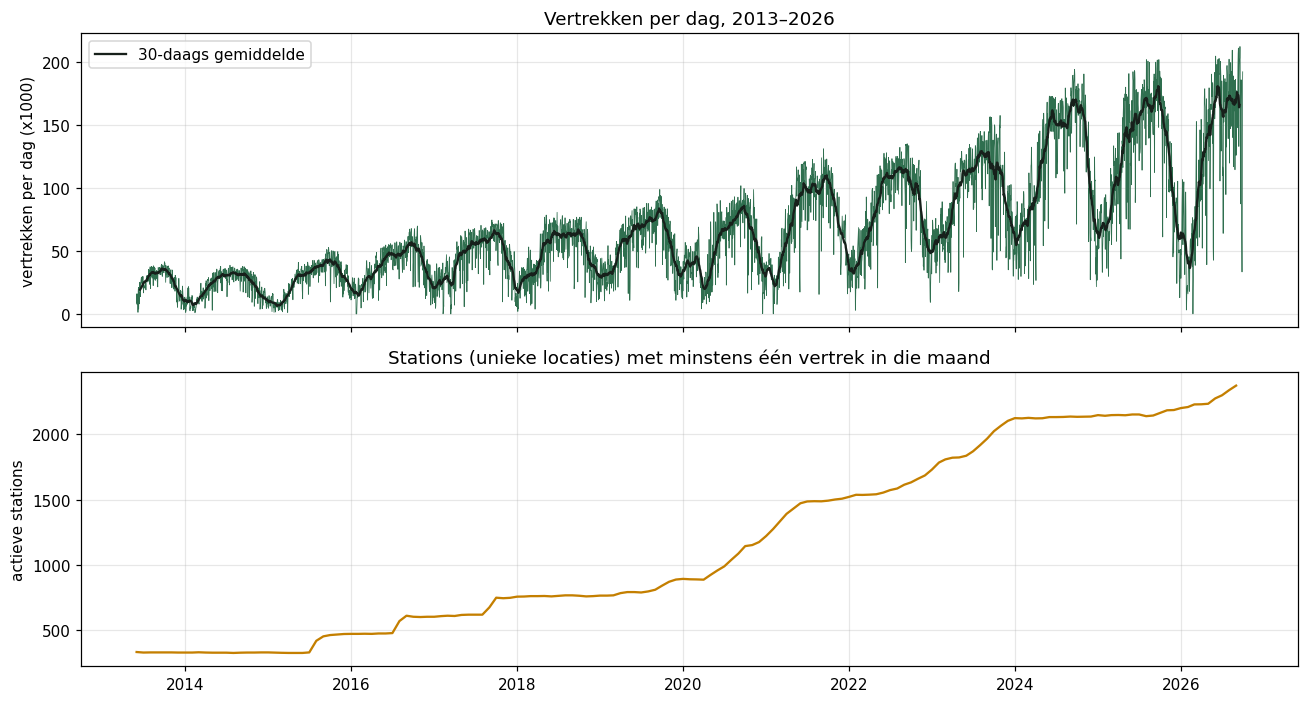

,trips,dagen met data,% member,% e-bike
2013,5613171,214,83.9,0.0
2014,8081216,365,90.2,0.0
2015,9937954,365,86.8,0.0
2016,13844352,362,88.8,0.0
2017,16362735,361,89.1,0.0
2018,17544527,365,89.0,0.0
2019,20551820,365,86.0,0.0
2020,19562091,366,77.0,14.1
2021,27129171,364,73.2,31.8
2022,29837939,365,77.9,39.3


In [9]:
public = cb.clean_stations(stations).query("keep")
kept = set(public["start_station_id"])
daily_parts, monthly_active = [], []
for path in sorted((cb.DATA_DIR / "station_hour").glob("*.parquet")):
    sh = pd.read_parquet(path, columns=["start_station_id", "time", "trips", "members", "electric"])
    sh = sh[sh["start_station_id"].isin(kept)]
    daily_parts.append(sh.groupby(sh["time"].dt.normalize())[["trips", "members", "electric"]].sum())
    monthly_active.append(sh.assign(m=sh["time"].dt.to_period("M"), loc=sh["start_station_id"].map(location))
                            [["m", "loc"]].drop_duplicates())
daily = pd.concat(daily_parts).groupby(level=0).sum()
daily = daily.reindex(pd.date_range(daily.index.min(), daily.index.max(), freq="D"), fill_value=0)
active = pd.concat(monthly_active).drop_duplicates().groupby("m").size()

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
axes[0].plot(daily.index, daily["trips"] / 1000, color=GREEN, lw=.5)
axes[0].plot(daily["trips"].rolling(30, center=True).mean() / 1000, color=INK, lw=1.5, label="30-daags gemiddelde")
axes[0].set(ylabel="vertrekken per dag (x1000)", title="Vertrekken per dag, 2013–2026"); axes[0].legend()
axes[1].plot(active.index.to_timestamp(), active.values, color=ORANGE)
axes[1].set(ylabel="actieve stations", title="Stations (unieke locaties) met minstens één vertrek in die maand")
plt.tight_layout()
plt.show()

yearly = daily.groupby(daily.index.year)[["trips", "members", "electric"]].sum()
yearly["dagen met data"] = daily.groupby(daily.index.year)["trips"].apply(lambda s: int((s > 0).sum()))
yearly["% member"] = (yearly["members"] / yearly["trips"] * 100).round(1)
yearly["% e-bike"] = (yearly["electric"] / yearly["trips"] * 100).round(1)
yearly[["trips", "dagen met data", "% member", "% e-bike"]]

**Interpretatie:** dertien jaar Citi Bike in twee grafieken:
- de vraag groeit van ± 35.000 vertrekken per dag in de zomer van 2013 naar ± 170.000 in de zomer van 2025 en 2026, altijd met hetzelfde **seizoenspatroon** (winterdal, zomer- en vroege-herfstpiek);
- het netwerk groeit in **sprongen** (onderste grafiek): van 330 stations naar ± 480 (2015), ± 750 (2017–2018), ± 1.500 (2021), ± 2.100 (2024) en ± 2.400 (2026). Elke sprong is een uitbreiding naar nieuwe buurten;
- **corona**: in het voorjaar van 2020 zakt de vraag even weg, daarna groeit ze sneller dan ooit (2021: +39%), met een veel hoger aandeel **casual** riders (14% in 2019 → 27% in 2021) en de snelle opkomst van **e-bikes** (0% → 73%).

**Gevolg voor het model:** een model dat alleen de kalender en het weer kent, zou de groei niet begrijpen. Daarom krijgt het het **jaar** (trend) en het **aantal actieve stations** in de zone (aanbod) als kenmerken.

### Dagen met (bijna) geen data
Een dag met heel weinig vertrekken kan echt zijn (sneeuwstorm, kerst) of een **gat in de data** (een bestand dat ontbreekt of afgekapt is). Voor het model is dat een groot verschil: een echte rustige dag moet het leren, een gat niet (dan zou het leren dat er "0 vraag" was). We vergelijken elke dag met de mediaan van de 4 weken eromheen.

In [10]:
rolling = daily["trips"].rolling(29, center=True, min_periods=10).median()
ratio = daily["trips"] / rolling
suspicious = daily.assign(mediaan_4_weken=rolling.round(), verhouding=ratio.round(3)).join(
    weather.set_index("time").resample("D").agg({"precipitation_mm": "sum", "snowfall_cm": "sum", "temperature_c": "mean"}).round(1))
suspicious = suspicious[suspicious["verhouding"] < 0.25]
suspicious[["trips", "mediaan_4_weken", "verhouding", "precipitation_mm", "snowfall_cm", "temperature_c"]]

,trips,mediaan_4_weken,verhouding,precipitation_mm,snowfall_cm,temperature_c
2013-06-07,1222,15735.0,0.078,45.0,0.0,16.1
2013-06-10,3887,16332.0,0.238,23.6,0.0,18.7
2014-01-03,1144,9999.0,0.114,10.1,7.1,-11.8
2014-01-04,2292,9847.0,0.233,0.0,0.0,-12.7
2014-01-22,2451,9999.0,0.245,0.5,0.7,-12.9
2014-02-13,876,8506.0,0.103,41.3,23.1,-0.7
2014-03-29,4480,18053.0,0.248,23.5,0.0,6.8
2014-04-30,2867,26762.0,0.107,34.9,0.0,7.7
2014-11-01,6002,25355.0,0.237,15.0,0.0,7.4
2014-11-26,3675,15367.0,0.239,24.6,6.7,3.9


**Interpretatie:** twee soorten heel rustige dagen:
- **gesloten systeem** (verhouding ± 0): 12 dagen met zware sneeuwstormen waarop Citi Bike de dienst stillegde, o.a. de blizzard van 23–26 januari 2016 (31 cm sneeuw), 14–16 maart 2017, 1–2 februari 2021 en 23 februari 2026. Er was geen aanbod, dus "0 vertrekken" zegt niets over de vraag. Die dagen sluiten we uit (`cb.EXCLUDE_DAYS`, regel: minder dan 3% van de mediaan van de 4 weken eromheen);
- **echt rustige dagen** (verhouding 0,07–0,25): zware regen (bv. 61 mm op 22 augustus 2021, de restanten van storm Henri), sneeuw, Kerstmis. Die blijven in de data: dat is precies wat het model moet leren.

Er zijn **geen gaten** door ontbrekende bestanden: elke maand is aanwezig en elke dag buiten de gesloten dagen heeft ritten.

In [11]:
monthly = daily["trips"].resample("MS").sum()
by_month = pd.DataFrame({"vertrekken": monthly, "dagen_met_data": (daily["trips"] > 0).resample("MS").sum(),
                         "dagen": monthly.index.days_in_month})
by_month["% van vorig jaar"] = (by_month["vertrekken"] / by_month["vertrekken"].shift(12) * 100).round()
by_month.loc[by_month.index >= "2025-01-01"]

,vertrekken,dagen_met_data,dagen,% van vorig jaar
2025-01-01,2123800,31,31,113.0
2025-02-01,2030549,28,28,96.0
2025-03-01,3166621,31,31,119.0
2025-04-01,3723059,30,30,116.0
2025-05-01,4323432,31,31,105.0
2025-06-01,4756486,30,30,99.0
2025-07-01,4983818,31,31,106.0
2025-08-01,5119526,31,31,111.0
2025-09-01,5284678,30,30,106.0
2025-10-01,4728867,31,31,92.0


**Interpretatie:** de recentste maanden (de testperiode van het model) zijn volledig. Februari 2026 ligt 40% onder februari 2025: een dag gesloten systeem (23/2) in de koudste februari van de reeks (gemiddeld −3,2 °C, 29 cm sneeuw). Het najaar van 2025 en januari 2026 liggen 8–15% lager dan een jaar eerder, de zomer van 2026 weer op of boven het niveau van 2025. Het model moet die schommelingen uit het weer en het seizoen halen.

## 7. Zones op het netwerk van vandaag
In 2024 legden we 30 zones met KMeans op de stations van dat jaar. Met 13 jaar data moeten we kiezen **welk** netwerk de zones bepaalt. Het model zal de toekomst voorspellen, dus nemen we het netwerk van de **laatste 12 maanden** (gewogen met de recente ritten). Elk station uit elk jaar, ook met een oude id, krijgt daarna de zone van zijn locatie.

Gevolg: in de beginjaren bestonden veel zones nog niet (de Bronx kwam er pas in 2022). Een zone-uur zonder enig actief station is geen "0 vraag" maar "geen aanbod". Die uren laten we in `04` weg, en het aantal **actieve stations** per zone en maand wordt een kenmerk, zodat het model weet hoe groot het aanbod op dat moment was.

Stations in de laatste 12 maanden: 2,433 (van 3,714 publieke id's ooit)


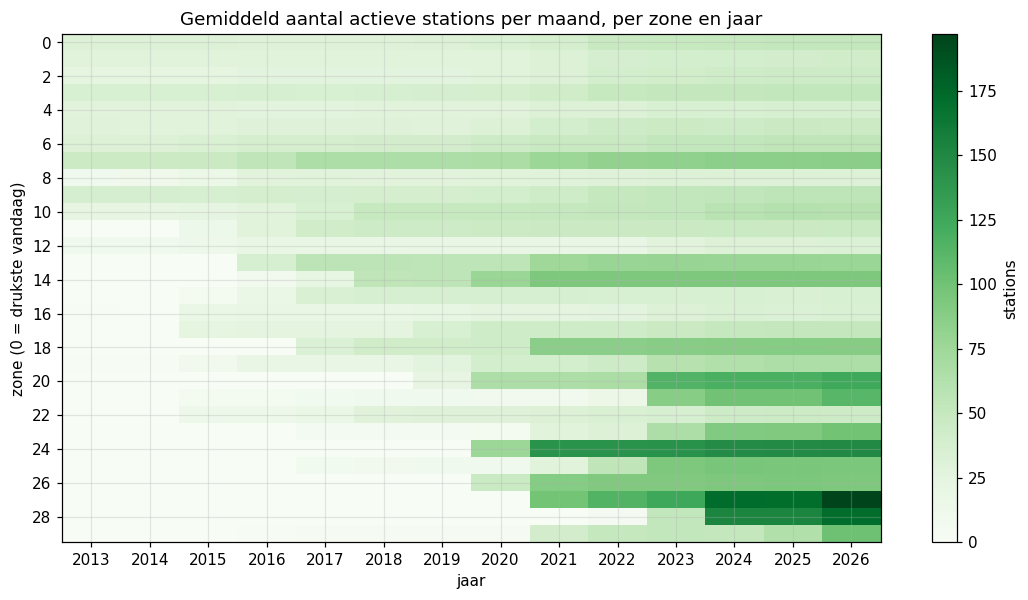

In [12]:
since = stations["last_time"].max() - pd.DateOffset(months=12)
recent = cb.recent_station_trips(cb.DATA_DIR / "station_hour", since)
current = public[public["start_station_id"].isin(recent.index)].assign(
    trips=lambda d: d["start_station_id"].map(recent).astype(int))
kmeans = cb.fit_zones(current, cb.N_ZONES)
zones = cb.zone_table(current, kmeans)
public = public.assign(zone=cb.assign_zones(public, kmeans, zones).to_numpy())
print(f"Stations in de laatste 12 maanden: {len(current):,} (van {len(public):,} publieke id's ooit)")

zone_of = public.set_index("start_station_id")["zone"]
monthly = ids_per_month.assign(zone=ids_per_month["start_station_id"].map(zone_of)).dropna(subset=["zone"])
monthly = monthly[["zone", "m", "locatie"]].drop_duplicates().groupby(["zone", "m"]).size().rename("actief").reset_index()
monthly["jaar"] = monthly["m"].dt.year
zone_years = monthly.groupby(["zone", "jaar"])["actief"].mean().unstack(fill_value=0).round()
zone_years.index = zone_years.index.astype(int)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(zone_years.values, aspect="auto", cmap="Greens")
ax.set(xticks=range(zone_years.shape[1]), xticklabels=zone_years.columns, yticks=range(0, cb.N_ZONES, 2),
       xlabel="jaar", ylabel="zone (0 = drukste vandaag)", title="Gemiddeld aantal actieve stations per maand, per zone en jaar")
plt.colorbar(im, ax=ax, label="stations")
plt.show()

**Interpretatie:** de zones met de laagste nummers (de drukste van vandaag: Midtown, Lower Manhattan, Williamsburg) bestaan al sinds 2013. De hoge nummers (de Bronx, Queens, East Harlem, Bushwick, Flatbush en Sunset Park) krijgen pas tussen 2019 en 2023 stations, en zones 27–28 groeien nog in 2026. Daarom:
- zone-uren met **0 actieve stations** worden weggelaten (`04`): in 2014 was er in de Bronx geen vraag te meten, niet "0 vraag";
- het aantal **actieve stations** is een kenmerk: een zone met 20 stations vraagt minder fietsen dan dezelfde zone met 150 stations.

Ook hier tellen we **locaties**, niet id's: anders zou de overstap op nieuwe id's (§5) in 2019 lijken op een plotse uitbreiding.

## 8. Weer over de hele periode

In [13]:
w = weather.set_index("time")
print(f"{w.index.min()} – {w.index.max()}: {len(w):,} uren, ontbrekend: {int(w.isna().sum().sum())}")
w.resample("Y").agg({"temperature_c": "mean", "precipitation_mm": "sum", "snowfall_cm": "sum"}).round(1).T

2013-06-01 00:00:00 – 2026-09-30 23:00:00: 116,880 uren, ontbrekend: 0


time,2013-12-31,2014-12-31,2015-12-31,2016-12-31,2017-12-31,2018-12-31,2019-12-31,2020-12-31,2021-12-31,2022-12-31,2023-12-31,2024-12-31,2025-12-31,2026-12-31
temperature_c,15.9,11.0,12.0,12.8,12.4,12.2,12.2,13.0,12.8,12.6,13.0,13.1,12.5,14.0
precipitation_mm,686.2,992.4,980.1,898.5,1102.4,1670.4,1328.9,1221.3,1367.5,1352.2,1479.7,1296.8,1104.4,1100.4
snowfall_cm,19.5,99.9,88.3,62.0,78.3,118.4,62.0,31.9,63.5,46.0,22.4,40.2,50.5,62.4


## Samenvatting van de keuzes (toegepast in `04_prepare_data`)
| Onderwerp | Vaststelling | Keuze |
|---|---|---|
| Bestanden | jaar-zip's met maandmappen, maand-zip's vanaf 2024; JC-bestanden apart | alle NYC-bestanden, JC niet |
| Dubbele bestanden | 2013 en 2018 bevatten elke maand twee keer | per maand één versie (`select_csvs`) |
| Kolommen | drie generaties namen | omzetten naar het schema van vandaag (`standardize_columns`) |
| Datums | drie notaties, wisselend per bestand | notatie per stuk bepalen (`to_datetime`); 0 onleesbaar |
| Station-id's | oud (`72`), nieuw (`6926.01`), als kommagetal opgeslagen | herstellen per periode; zones en actieve stations via **locatie** |
| Dubbele rijen 2013–2017 | waarschijnlijk groepsritten | behouden |
| Gesloten systeem | 12 sneeuwstormdagen met ± 0 ritten | weglaten (`EXCLUDE_DAYS`) |
| Groei | 330 → 2.400 stations, 5,6 → 45,8 miljoen ritten per jaar | kenmerken `year` en `active_stations`; zone-uren zonder aanbod weglaten |
| Zones | netwerk verandert | 30 zones op het netwerk van de laatste 12 maanden |